# Satellite Image Sequence Analysis for Environmental Monitoring
## Overview
This project leverages **Sentinel-2 Satellite Imagery** and **Deep Learning (ConvLSTM)** to monitor land-use changes and environmental degradation over time. By analyzing yearly composites (2020–2026), the system calculates vegetation indices (NDVI) and predicts both land classifications and forest loss using a multi-output neural network.

## Table of Contents
1. [Project Structure](#project-structure)
2. [Data Pipeline](#data-pipeline)
3. [Methodology](#methodology)
4. [Model Architecture](#model-architecture)
5. [Key Metrics](#key-metrics)

## Project Structure
The workflow is divided into modular functions to ensure scalability and clarity:
* **`import_libraries()`**: Configures the environment with TensorFlow, Google Earth Engine (GEE), and Geospatial tools like `rasterio` and `geemap`.
* **`earth_engine()`**: Handles authentication and initialization of the Google Earth Engine API.
* **`data_wrangling()`**: Fetches multi-spectral satellite data (Bands 4, 3, 2, 8) for specified geographic locations.
* **`create_sequence_patches()`**: Generates 64x64 pixel image sequences across a 7-year timeline.
* **`automated_sequence_labeling()`**: Applies environmental logic to label data based on NDVI thresholds.

In [1]:
def import_libraries():
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import warnings
    %matplotlib inline
    warnings.filterwarnings("ignore")
    import tensorflow as tf
    import geemap
    import ee
    import os
    from dotenv import load_dotenv
    from rasterio.windows import Window
    import rasterio
    import shutil
    import keras
    import collections
    import random
    import seaborn as sns
    import folium
    import pickle
    from tensorflow.keras import layers,models
    from tensorflow.keras.layers import TimeDistributed 
    from tensorflow.keras.optimizers import Adam
    from sklearn.model_selection import train_test_split
    from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
    from tensorflow.keras.layers import GlobalAveragePooling2D,Attention
    from sklearn.metrics import confusion_matrix, classification_report
    from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array,load_img
    from tensorflow.keras.layers import ConvLSTM2D, Dropout, Dense
    return np,pd,plt,warnings,tf,ee,os,load_dotenv,geemap,Window,rasterio,shutil,layers,models,keras,ImageDataGenerator,img_to_array,load_img,random,TimeDistributed,train_test_split,collections,EarlyStopping,Adam,ReduceLROnPlateau,sns,confusion_matrix,classification_report,folium,pickle,ConvLSTM2D,Dropout,Dense,GlobalAveragePooling2D,Attention

np,pd,plt,warnings,tf,ee,os,load_dotenv,geemap,Window,rasterio,shutil,layers,models,keras,ImageDataGenerator,img_to_array,load_img,random,TimeDistributed,train_test_split,collections,EarlyStopping,Adam,ReduceLROnPlateau,sns,confusion_matrix,classification_report,folium,pickle,ConvLSTM2D,Dropout,Dense,GlobalAveragePooling2D,Attention= import_libraries()
print("Import done")
    

Import done


In [ ]:
def earth_engine():
    load_dotenv()
    print("Dotenv loaded successfully")
    project_id = os.getenv("GEE_PROJECT_ID")
    try:
        ee.Authenticate(force=True, auth_mode='notebook')
        ee.Initialize(project=project_id)
        print(f"Initailzation process done successfully with project id :{project_id}")
    except Exception as e:
        print("Existing credentials not found or expired. Authenticating...")
        try:
            ee.Authenticate(auth_mode="localhost")
            ee.Initialize(project=project_id)
            print(f"Initailzation process done successfully with project id :{project_id}")
        except Exception as e:    
            print(f"Initialization process failed.Check Your Project Id  as Error:{e} ")    

    return project_id
project_id = earth_engine()

Dotenv loaded successfully
Initailzation process done successfully with project id :556875452242


## Data Pipeline
### 1. Spatial Coverage
The project monitors 18 strategic locations including Manesar, Sohna, Mangar, Pali, and Nuh etc.

### 2. Spectral Indices
The core analytical unit is the **Normalized Difference Vegetation Index (NDVI)**, calculated using Sentinel-2 Bands 4 (Red) and 8 (NIR):
$$NDVI = \frac{B8 (NIR) - B4 (Red)}{B8 (NIR) + B4 (Red) + 1e^{-10}}$$

In [3]:
locations = [
    {"name": "manesar-south", "coords": [76.9900, 28.3000]},
    {"name": "manesar-north", "coords": [76.9900, 28.3500]},
    {"name": "sohna-south",   "coords": [77.0500, 28.2200]},
    {"name": "sohna-north",   "coords": [77.0500, 28.2700]},
    {"name": "mangar-south",  "coords": [77.1731, 28.3500]},
    {"name": "mangar-north",  "coords": [77.1731, 28.4000]},
    {"name": "pali-south",    "coords": [77.2100, 28.3100]},
    {"name": "pali-north",    "coords": [77.2100, 28.3600]},
    {"name": "nuh-north",     "coords": [77.0100, 28.1500]}, 
    {"name": "nuh-south",     "coords": [77.0200, 27.8500]},
    {"name": "mining-pali",    "coords": [77.2285, 28.3412]},
    {"name": "mining-mewat",   "coords": [77.0421, 27.9150]},
    {"name": "mining-farid",   "coords": [77.2850, 28.4120]},
    {"name": "degradation-khetri", "coords": [75.7800, 28.0000]},
    {"name": "degradation-makrana", "coords": [74.7200, 26.8800]},
    {"name": "desert-gap-ajmer", "coords": [74.6300, 26.4500]},
    {"name": "degradation-bhilwara", "coords": [74.6400, 25.3500]},
    {"name": "degradation-chittorgarh", "coords": [74.6200, 24.8800]}
]



def get_yearly_composite(year):
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterDate(start, end)
                  .select(['B4', 'B3', 'B2', 'B8']))

    size = collection.size().getInfo()

    if size == 0:
        print(f"No images for year {year}")
        return None

    return collection.median()

In [4]:
def data_wrangling():

    exports = []

    for loc in locations:

        name = loc["name"]
        target_point = ee.Geometry.Point(loc["coords"])
        roi = target_point.buffer(320).bounds()

        for year in range(2020, 2027):

            filename = f"{name}_{year}.tif"

            if os.path.exists(filename):
                print(filename, "already exists")
                continue

            image = get_yearly_composite(year).clip(roi)

            geemap.ee_export_image(
                image,
                filename=filename,
                scale=10,
                region=roi
            )

        exports.append(name)

    return exports
data_wrangling()


manesar-south_2020.tif already exists
manesar-south_2021.tif already exists
manesar-south_2022.tif already exists
manesar-south_2023.tif already exists
manesar-south_2024.tif already exists
manesar-south_2025.tif already exists
manesar-south_2026.tif already exists
manesar-north_2020.tif already exists
manesar-north_2021.tif already exists
manesar-north_2022.tif already exists
manesar-north_2023.tif already exists
manesar-north_2024.tif already exists
manesar-north_2025.tif already exists
manesar-north_2026.tif already exists
sohna-south_2020.tif already exists
sohna-south_2021.tif already exists
sohna-south_2022.tif already exists
sohna-south_2023.tif already exists
sohna-south_2024.tif already exists
sohna-south_2025.tif already exists
sohna-south_2026.tif already exists
sohna-north_2020.tif already exists
sohna-north_2021.tif already exists
sohna-north_2022.tif already exists
sohna-north_2023.tif already exists
sohna-north_2024.tif already exists
sohna-north_2025.tif already exists


['manesar-south',
 'manesar-north',
 'sohna-south',
 'sohna-north',
 'mangar-south',
 'mangar-north',
 'pali-south',
 'pali-north',
 'nuh-north',
 'nuh-south',
 'mining-pali',
 'mining-mewat',
 'mining-farid',
 'degradation-khetri',
 'degradation-makrana',
 'desert-gap-ajmer',
 'degradation-bhilwara',
 'degradation-chittorgarh']

In [5]:
def create_sequence_patches(locations):
    patch_dir = "dataset/Sequence_Patches"

    if os.path.exists(patch_dir):
        shutil.rmtree(patch_dir)

    os.makedirs(patch_dir, exist_ok=True)

    total_patches = 0

    for loc in locations:
        loc_name = loc["name"]

        # Load 7 yearly images
        yearly_images = []
        for year in range(2020, 2027):
            tif_file = f"{loc_name}_{year}.tif"
            if not os.path.exists(tif_file):
                print(f"{tif_file} not found")
                continue

            src = rasterio.open(tif_file)
            yearly_images.append(src)

        if len(yearly_images) != 7:
            print(f"Skipping {loc_name}, incomplete years")
            continue

        height = yearly_images[0].height
        width = yearly_images[0].width

        for i in range(0, height - 64 + 1):
            for j in range(0, width - 64 + 1):

                sequence = []

                for src in yearly_images:
                    window = Window(j, i, 64, 64)
                    patch = src.read(window=window)
                    sequence.append(patch)

                sequence = np.stack(sequence, axis=0)  
                sequence = np.transpose(sequence, (0,2,3,1))  

                np.save(f"{patch_dir}/{loc_name}_{i}_{j}.npy", sequence)

                total_patches += 1

        for src in yearly_images:
            src.close()

    print(f"Total sequence patches: {total_patches}")
    return total_patches
create_sequence_patches(locations)
print("Patches Created Successfully")

Total sequence patches: 360
Patches Created Successfully


### 3. Classification Logic
Land is categorized based on its 2026 NDVI values:
* **Class 0**: Active mining / Barren land (NDVI < 0.25)
* **Class 1**: Sparse/Moderate vegetation (0.25 ≤ NDVI < 0.50)
* **Class 2**: Dense vegetation / Forest (NDVI ≥ 0.50)

In [6]:
def automated_sequence_labeling():

    source_folder = "dataset/Sequence_Patches"

    X = []
    y_class = []
    y_loss = []

    for file in os.listdir(source_folder):

        if not file.endswith(".npy"):
            continue

        sequence = np.load(os.path.join(source_folder, file))
        ndvi_sequence = (sequence[:,:,:,3] - sequence[:,:,:,0]) / \
                        (sequence[:,:,:,3] + sequence[:,:,:,0] + 1e-10)

        
        ndvi_2026_mean = np.mean(ndvi_sequence[-1])

        if ndvi_2026_mean < 0.25:
            class_label = 0
        elif 0.25 <= ndvi_2026_mean < 0.5:
            class_label = 1
        else:
            class_label = 2
        ndvi_2020_mean = np.mean(ndvi_sequence[0])
        forest_loss = ndvi_2020_mean - ndvi_2026_mean

        X.append(sequence)
        y_class.append(class_label)
        y_loss.append(forest_loss)

    X = np.array(X)
    y_class = np.array(y_class)
    y_loss = np.array(y_loss)

    print("Dataset prepared")
    print("Shape:", X.shape)

    return X, y_class, y_loss
X, y_class, y_loss = automated_sequence_labeling()
print("Class labels shape:", y_class.shape)
print("Loss labels shape:", y_loss.shape)

Dataset prepared
Shape: (360, 7, 64, 64, 4)
Class labels shape: (360,)
Loss labels shape: (360,)


In [7]:
def train_test(X, y_class, y_loss):

    X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss = train_test_split(
        X,
        y_class,
        y_loss,
        test_size=0.4,
        random_state=42,
        stratify=y_class
    )

    return X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss
X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss = train_test(X, y_class, y_loss)
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test.shape)

Train shape: (216, 7, 64, 64, 4)
Test shape: (144, 7, 64, 64, 4)


## 4. Methodology
### 4.1 Data Augmentation
To improve model robustness, the training set is expanded using spatial flips, signal noise, and radiometric adjustments (brightness scaling).

### 4.2 Preprocessing
* **Standardization**: Data is normalized using the mean and standard deviation of the training set.
* **Splitting**: A 60/40 stratified split is used to maintain class balance between training and testing.

In [8]:
def standarization(X_train_raw, X_test):

    mean = np.mean(X_train_raw, axis=(0,1,2,3), keepdims=True)
    std = np.std(X_train_raw, axis=(0,1,2,3), keepdims=True) + 1e-8

    X_train_norm = (X_train_raw - mean) / std
    X_test_norm = (X_test - mean) / std

    return X_train_norm, X_test_norm


X_train_norm, X_test_norm = standarization(X_train_raw, X_test)


In [9]:
def augment_sequence_data(X, y_c, y_l):
    X_aug = []
    y_c_aug = []
    y_l_aug = []

    for i in range(len(X)):
        img = X[i]
        label_c = y_c[i]
        label_l = y_l[i]

        augs = [img, np.flip(img, axis=2), np.flip(img, axis=1)]
        
        for augmented_img in augs:
            X_aug.append(augmented_img)
            y_c_aug.append(label_c)
            y_l_aug.append(label_l)

        noise = np.random.normal(0, 0.01, img.shape)
        X_aug.append(np.clip(img + noise, -3, 3))
        y_c_aug.append(label_c)
        y_l_aug.append(label_l)

        bright = np.random.uniform(0.9,1.1)
        X_aug.append(np.clip(img * bright, -3, 3))
        y_c_aug.append(label_c)
        y_l_aug.append(label_l)

    return np.array(X_aug), np.array(y_c_aug), np.array(y_l_aug)
X_train_final, y_train_class_final, y_train_loss_final = augment_sequence_data(
    X_train_norm, y_train_class, y_train_loss
)
print(f"X_train_final :{X_train_final.shape}")

X_train_final :(1080, 7, 64, 64, 4)


## 5. Model Architecture
The project utilizes a **Functional API** approach in TensorFlow to create a multi-output model:
* **TimeDistributed (Conv2D)**: Extracts spatial features from each year in the sequence.
* **ConvLSTM2D**: Captures temporal dependencies and "movement" in land use over time.
* **Multi-Output Head**: Simultaneous **Classification** (Softmax) and **Regression** for forest loss.

In [ ]:
def build_regression_model_with_attention(input_shape=(7, 64, 64, 4)):
    inputs = layers.Input(shape=input_shape)
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=True)(x)
    x = layers.BatchNormalization()(x)
    time_steps = input_shape[0]
    x_reshaped = layers.Reshape((time_steps, -1))(x) 
    scores = layers.TimeDistributed(layers.Dense(1))(x_reshaped)
    scores = layers.Flatten()(scores) 
    weights = layers.Activation('softmax', name='temporal_attention_weights')(scores)
    weights = layers.Reshape((time_steps, 1))(weights)
    x_final = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)
    x = layers.Dense(128, activation='relu')(x_final)
    x = layers.Dropout(0.3)(x)

    loss_output = layers.Dense(
        1, 
        activation='linear', 
        dtype='float32', 
        name="loss_output"
    )(x)

    model = models.Model(inputs, loss_output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.Huber(delta=1.0), 
        metrics=['mae']
    )

    return model

model = build_regression_model_with_attention()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 64, 64, │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 7, 64, 64, │      1,184 │ input_layer[0][0] │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 7, 64, 64, │      9,248 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 7, 64, 64, │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 7, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 7, 32, 32, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 7, 16, 16, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 7, 16, 16, │    295,168 │ time_distributed… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 16, 16, │        256 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 16384)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 7, 1)      │     16,385 │ reshape[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7)         │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention… │ (None, 7)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 1)      │          0 │ temporal_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 16384)  │          0 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 16384)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  2,097,280 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loss_output (Dense) │ (None, 1)         │        129 │ dropout[0][0]   

 Total params: 2,438,274 (9.30 MB)

 Trainable params: 2,438,082 (9.30 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - loss: 0.2184 - mae: 0.4525 - val_loss: 0.0239 - val_mae: 0.1860 - learning_rate: 1.0000e-04
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 967ms/step - loss: 0.0045 - mae: 0.0712 - val_loss: 0.0105 - val_mae: 0.1178 - learning_rate: 1.0000e-04
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 67s 982ms/step - loss: 0.0033 - mae: 0.0581 - val_loss: 0.0064 - val_mae: 0.0915 - learning_rate: 1.0000e-04
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 973ms/step - loss: 0.0029 - mae: 0.0530 - val_loss: 0.0036 - val_mae: 0.0644 - learning_rate: 1.0000e-04
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 975ms/step - loss: 0.0027 - mae: 0.0518 - val_loss: 0.0030 - val_mae: 0.0558 - learning_rate: 1.0000e-04
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 973ms/step - loss: 0.0024 - mae: 0.0470 - val_loss: 9.3211e-04 - val_mae: 0.0302 - learning_rate: 1.0000e-04
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 67s 986ms/step - loss: 0.0020 - mae: 0.0429 - val_loss: 9.5564e-04 - val_mae: 0

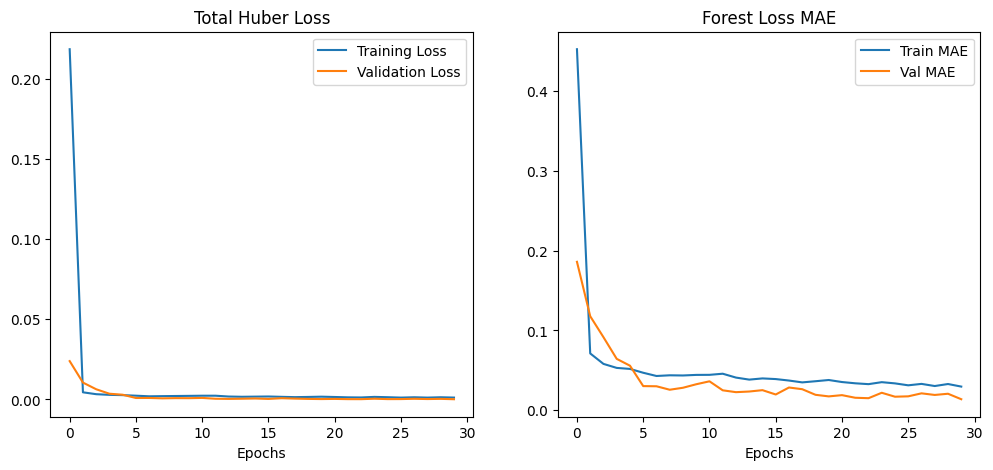

In [11]:
def model_trained():
    early_stop = EarlyStopping(monitor='val_mae', patience=8, restore_best_weights=True)
    lr_reduce = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=4, min_lr=1e-6)

    history = model.fit(
        X_train_final,
        y_train_loss_final, 
        validation_data=(
            X_test_norm,
            y_test_loss    
        ),
        epochs=30,         
        batch_size=16,
        shuffle=True,
        callbacks=[early_stop, lr_reduce]
    )

    plt.figure(figsize=(12, 5))

  
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Total Huber Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    mae_key = 'mae' if 'mae' in history.history else 'mean_absolute_error'
    val_mae_key = 'val_' + mae_key
    
    plt.plot(history.history[mae_key], label='Train MAE')
    plt.plot(history.history[val_mae_key], label='Val MAE')
    plt.title('Forest Loss MAE')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()
    return history

history = model_trained()

In [12]:
def hypertune_model_trained():
    
    early_stop_fine = EarlyStopping(monitor='val_mae', patience=4, restore_best_weights=True)
    lr_reducer_fine = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3, min_lr=1e-7)

    model.compile(
        optimizer=Adam(learning_rate=2e-5),
        loss=tf.keras.losses.Huber(), 
        metrics=['mae']
    )

    y_train = np.array(y_train_loss_final, dtype='float32').reshape(-1, 1)
    y_val = np.array(y_test_loss, dtype='float32').reshape(-1, 1)

   
    history_finetune = model.fit(
        X_train_final,
        y_train,
        validation_data=(X_test_norm, y_val),
        epochs=10,
        batch_size=16,
        shuffle=True,
        callbacks=[early_stop_fine, lr_reducer_fine]
    )

    return history_finetune

history_finetune = hypertune_model_trained()

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 81s 953ms/step - loss: 9.7818e-04 - mae: 0.0290 - val_loss: 1.6528e-04 - val_mae: 0.0142 - learning_rate: 2.0000e-05
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 64s 935ms/step - loss: 0.0011 - mae: 0.0290 - val_loss: 1.4768e-04 - val_mae: 0.0138 - learning_rate: 2.0000e-05
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 63s 931ms/step - loss: 0.0014 - mae: 0.0325 - val_loss: 2.0165e-04 - val_mae: 0.0164 - learning_rate: 2.0000e-05
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 64s 939ms/step - loss: 0.0011 - mae: 0.0287 - val_loss: 1.6930e-04 - val_mae: 0.0142 - learning_rate: 2.0000e-05
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 63s 929ms/step - loss: 0.0013 - mae: 0.0313 - val_loss: 1.5811e-04 - val_mae: 0.0143 - learning_rate: 2.0000e-05
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 63s 928ms/step - loss: 0.0013 - mae: 0.0295 - val_loss: 2.4300e-04 - val_mae: 0.0151 - learning_rate: 1.0000e-05


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 690ms/step
Worst indices: [ 48  26  85  35  65  46 133  75  15]


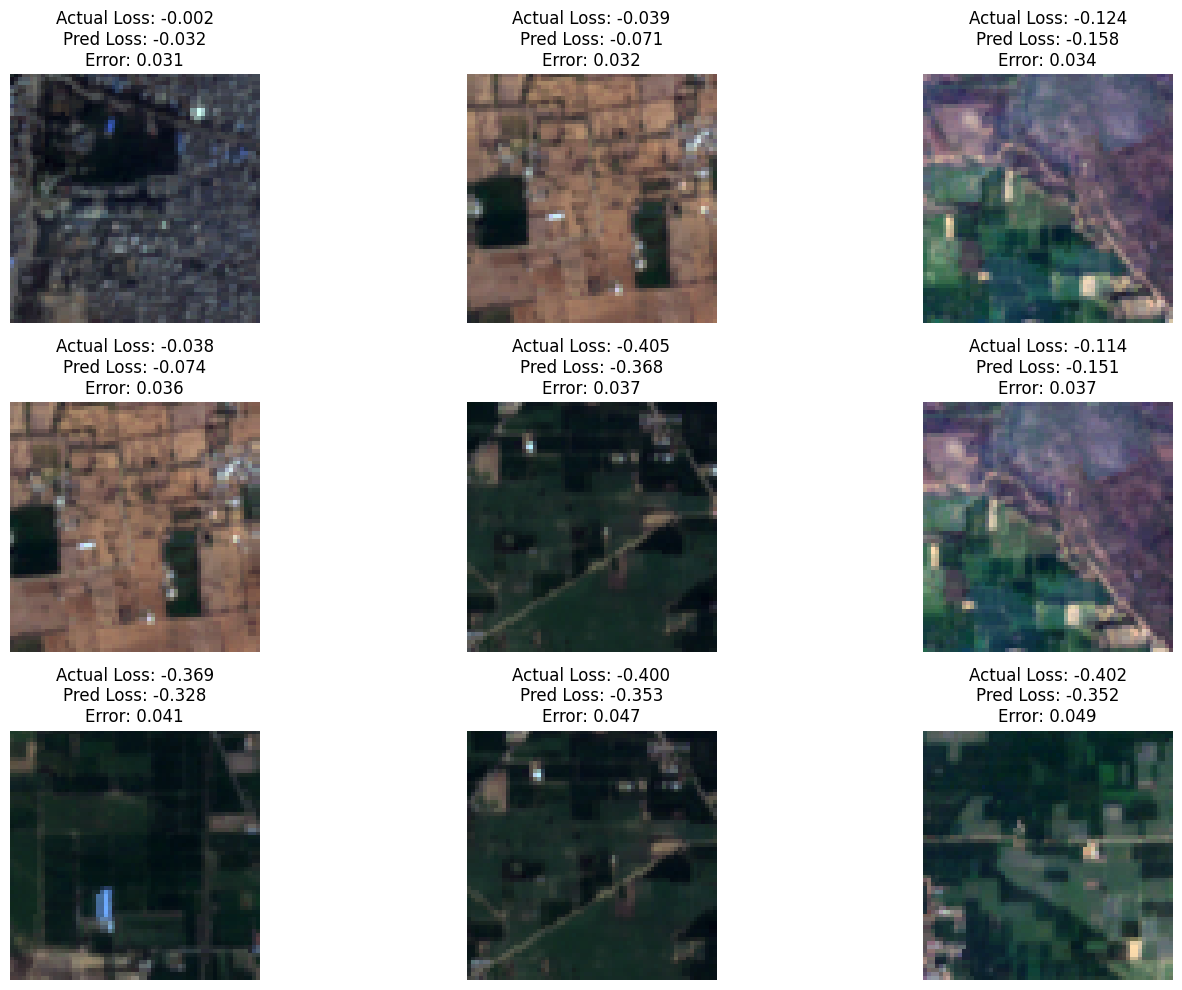

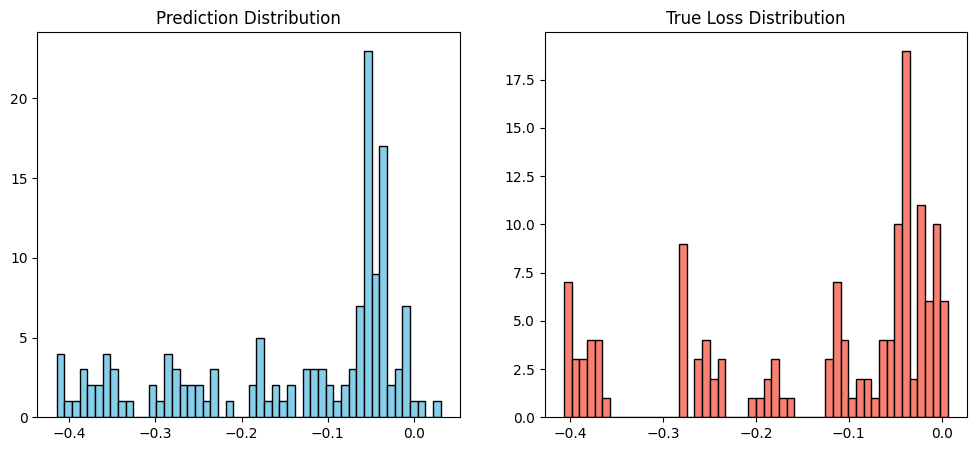

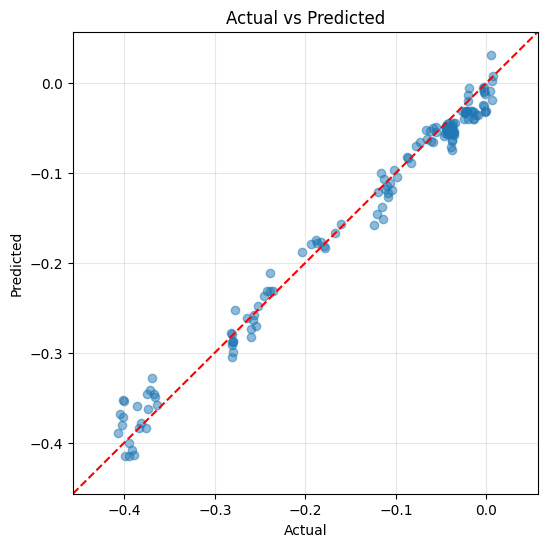

R2 Score: 0.9839
MAE: 0.0138


In [13]:
def testing():
    y_pred_loss = model.predict(X_test_norm)
    y_pred_loss = y_pred_loss.flatten()
    y_true_loss = y_test_loss.flatten()

    
    errors = np.abs(y_pred_loss - y_true_loss)

    worst_indices = np.argsort(errors)[-9:]
    print("Worst indices:", worst_indices)

   
    plt.figure(figsize=(15,10))
    for i, idx in enumerate(worst_indices):
        plt.subplot(3,3,i+1)        
        img = X_test_norm[idx,6,:,:,:3]
        img = (img - img.min())/(img.max()-img.min()+1e-8)

        plt.imshow(img)
        plt.title(
            f"Actual Loss: {y_true_loss[idx]:.3f}\n"
            f"Pred Loss: {y_pred_loss[idx]:.3f}\n"
            f"Error: {errors[idx]:.3f}"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.hist(y_pred_loss, bins=50, color='skyblue', edgecolor='black')
    plt.title("Prediction Distribution")
    
    plt.subplot(1,2,2)
    plt.hist(y_true_loss, bins=50, color='salmon', edgecolor='black')
    plt.title("True Loss Distribution")
    plt.show()
    plt.figure(figsize=(6,6))
    plt.scatter(y_true_loss, y_pred_loss, alpha=0.5)
    mn, mx = y_true_loss.min() - 0.05, y_true_loss.max() + 0.05
    plt.plot([mn, mx], [mn, mx], color='red', linestyle='--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.xlim(mn, mx)
    plt.ylim(mn, mx)
    plt.grid(True, alpha=0.3)
    plt.show()

    
    from sklearn.metrics import r2_score, mean_absolute_error
    print(f"R2 Score: {r2_score(y_true_loss, y_pred_loss):.4f}")
    print(f"MAE: {mean_absolute_error(y_true_loss, y_pred_loss):.4f}")

    return y_pred_loss

y_pred_loss = testing()

In [15]:
def degradation_proof(model, X_test_norm):
    pred_loss = model.predict(X_test_norm)
    pred_loss = pred_loss.flatten()

    print("\nAravali Forest Degradation Report Generated (Regression Only)\n")
    print(f"{'Patch ID':<10} | {'Status':<20} | {'Forest Loss'} | Condition")
    print("-" * 70)

    for i in range(len(pred_loss)):
        loss_val = pred_loss[i]
        if loss_val <= -0.25:
            label = "Mining / Degradation"
            condition = "🔴 CRITICAL"
        elif -0.25 < loss_val <= -0.10:
            label = "Degraded Scrub"
            condition = "🟡 DEGRADED"
        else:
            label = "Healthy Forest"
            condition = "🟢 STABLE"

        print(f"{i:<10} | {label:<20} | {loss_val:<10.3f} | {condition}")

    return pred_loss

pred_loss = degradation_proof(model, X_test_norm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step

Aravali Forest Degradation Report Generated (Regression Only)

Patch ID   | Status               | Forest Loss | Condition
----------------------------------------------------------------------
0          | Healthy Forest       | -0.031     | 🟢 STABLE
1          | Mining / Degradation | -0.305     | 🔴 CRITICAL
2          | Degraded Scrub       | -0.188     | 🟡 DEGRADED
3          | Healthy Forest       | -0.055     | 🟢 STABLE
4          | Mining / Degradation | -0.408     | 🔴 CRITICAL
5          | Mining / Degradation | -0.358     | 🔴 CRITICAL
6          | Degraded Scrub       | -0.175     | 🟡 DEGRADED
7          | Healthy Forest       | -0.031     | 🟢 STABLE
8          | Mining / Degradation | -0.359     | 🔴 CRITICAL
9          | Mining / Degradation | -0.263     | 🔴 CRITICAL
10         | Degraded Scrub       | -0.107     | 🟡 DEGRADED
11         | Healthy Forest       | -0.049     | 🟢 STABLE
12         | Degraded Scrub       | -0.104     | 🟡 DEG

In [16]:
def mapping():
    X_full = np.concatenate((X_train_norm, X_test_norm), axis=0)
    y_pred_final = model.predict(X_full).flatten()

    m = folium.Map(location=[28.45, 77.02], zoom_start=10, tiles='CartoDB positron')

    for loc, score in zip(locations, y_pred_final):
        
        if score <= -0.25:
            color = "red"
            status = "Critical Loss (Mining/Degradation)"
        elif -0.25 < score <= -0.10:
            color = "orange"
            status = "Moderate Degradation"
        else:
            color = "green"
            status = "Stable Forest"
            
        lon, lat = loc["coords"]
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            popup=(f"<b>{loc['name']}</b><br>"
                   f"Status: {status}<br>"
                   f"Forest Loss Index: {score:.3f}"),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7
        ).add_to(m)

    m.save("Aravalli_Forest_Risk_Map.html")
    print("Map generated: Aravalli_Forest_Risk_Map.html")
    return m 

m = mapping()
m

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step
Map generated: Aravalli_Forest_Risk_Map.html


In [17]:
def amount_degradation():
    X_full = np.concatenate((X_train_norm, X_test_norm), axis=0)
    y_pred_final = model.predict(X_full).flatten()
   
    area_per_patch = 1.0 
    total_degraded_area_km2 = 0

    print(f"{'Location':<20} | {'Loss Index':<12} | {'Estimated Loss (km2)'}")
    print("-" * 60)

    for loc, loss_index in zip(locations, y_pred_final):
        if loss_index < 0:
            loss_fraction = abs(loss_index) 
            patch_loss_km2 = loss_fraction * area_per_patch
        else:
            patch_loss_km2 = 0 

        total_degraded_area_km2 += patch_loss_km2
        
        print(f"{loc['name']:<20} | {loss_index:<12.3f} | {patch_loss_km2:.3f} sq. km")

    print(f"\nTOTAL ARAVALLI DEGRADATION DETECTED: {total_degraded_area_km2:.2f} sq. km")
    
    return y_pred_final

y_pred_final = amount_degradation()

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step
Location             | Loss Index   | Estimated Loss (km2)
------------------------------------------------------------
manesar-south        | -0.051       | 0.051 sq. km
manesar-north        | -0.055       | 0.055 sq. km
sohna-south          | -0.082       | 0.082 sq. km
sohna-north          | -0.047       | 0.047 sq. km
mangar-south         | -0.135       | 0.135 sq. km
mangar-north         | -0.245       | 0.245 sq. km
pali-south           | -0.187       | 0.187 sq. km
pali-north           | -0.364       | 0.364 sq. km
nuh-north            | -0.366       | 0.366 sq. km
nuh-south            | -0.409       | 0.409 sq. km
mining-pali          | -0.031       | 0.031 sq. km
mining-mewat         | -0.053       | 0.053 sq. km
mining-farid         | -0.031       | 0.031 sq. km
degradation-khetri   | -0.195       | 0.195 sq. km
degradation-makrana  | -0.031       | 0.031 sq. km
desert-gap-ajmer     | -0.031       | 0.031 sq. km
degradation-bhilwara | 

In [22]:
def model_saving():
    saved_model = model.save_weights("aravali_forest_model_v2.weights.h5")
    print("✅ Model weights saved successfully")
    return saved_model

saved_model = model_saving()
saved_model

✅ Model weights saved successfully


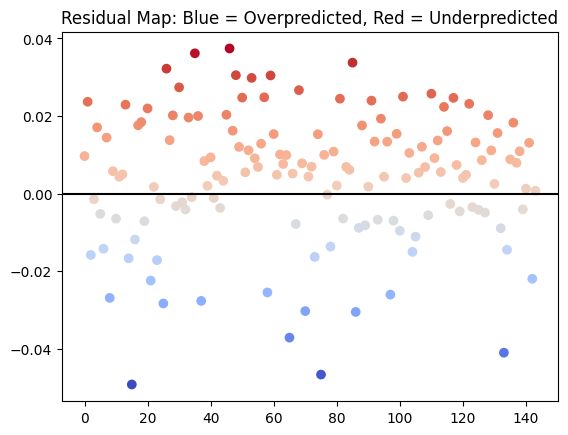

In [ ]:
y_pred_loss = y_pred_loss.flatten()
y_true_loss = y_test_loss.flatten()
residual_map = (y_true_loss - y_pred_loss)
plt.scatter(range(len(residual_map)), residual_map, c=residual_map, cmap='coolwarm')
plt.axhline(0, color='black')
plt.title("Residual Map: Blue = Overpredicted, Red = Underpredicted")
plt.show()

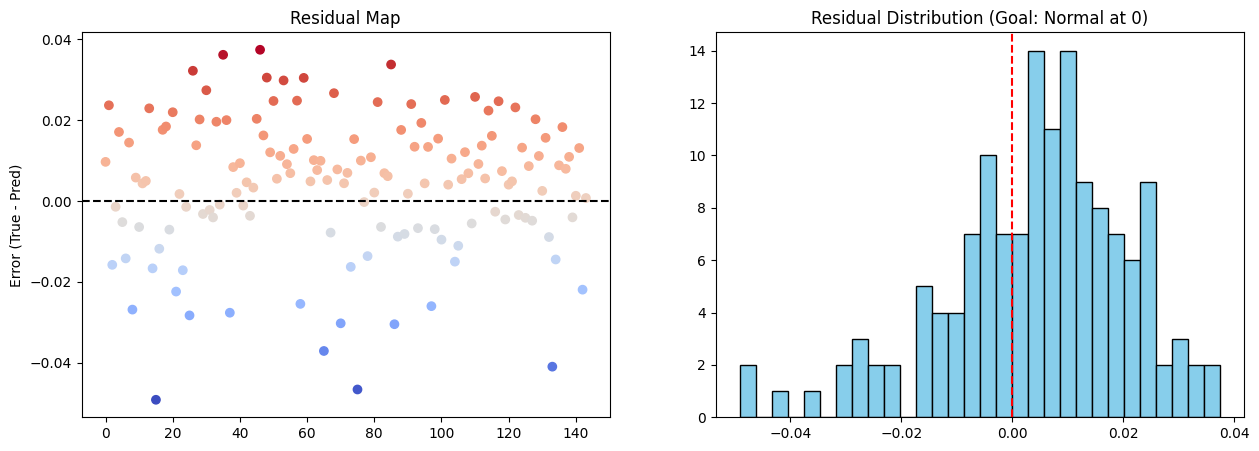

In [20]:
import matplotlib.pyplot as plt

# Your existing code
y_pred_loss = y_pred_loss.flatten()
y_true_loss = y_test_loss.flatten()
residual_map = (y_true_loss - y_pred_loss)

# Enhanced Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scatter Plot
sc = ax1.scatter(range(len(residual_map)), residual_map, c=residual_map, cmap='coolwarm')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title("Residual Map")
ax1.set_ylabel("Error (True - Pred)")

# Histogram (The Check for Bias)
ax2.hist(residual_map, bins=30, color='skyblue', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title("Residual Distribution (Goal: Normal at 0)")

plt.show()